In [4]:
# S&P 500 Stock Data — Exploratory Data Analysis 
# Dataset: S&P 500 historical prices (Kaggle)
# Author: Lorenzo Roma 
# Goal: Understand price behaviour, distributions, and volume patterns before building any forecasting model.


In [7]:
pip install pandas numpy matplotlib seaborn jupyter

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)

   ---------------------------------------- 0/6 [fonttools]
   ---------------------------------------- 0/6 [fonttools]
   ---------------------------------------- 0/6 [fonttools]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded.")

All libraries loaded.


In [20]:
df = pd.read_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/sp500_stocks.csv', parse_dates = ['Date'] )
df.columns = df.columns.str.lower().str.strip()

print(f"Rows:       {df.shape[0]:,}")
print(f"Columns:    {df.shape[1]}")#
#print(list(df.columns))

print(f"Tickers:    {df['symbol'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head(10)

Rows:       1,891,536
Columns:    8
Tickers:    502
Date range: 2010-01-04 to 2024-12-20


,date,symbol,adj close,close,high,low,open,volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN
5,2010-01-11,MMM,NaN,NaN,NaN,NaN,NaN,NaN
6,2010-01-12,MMM,NaN,NaN,NaN,NaN,NaN,NaN
7,2010-01-13,MMM,NaN,NaN,NaN,NaN,NaN,NaN
8,2010-01-14,MMM,NaN,NaN,NaN,NaN,NaN,NaN
9,2010-01-15,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
'TSLA' in df['symbol'].values

True

In [24]:
# 1. Data Quality Before any analysis we check for missing values, data types, and duplicates. 
# This is the first step in any professional data pipeline.

In [25]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== Summary Stats ===")
df[['open','high','low','close','volume']].describe().round(2)

=== Missing Values ===
date               0
symbol             0
adj close    1273705
close        1273705
high         1273705
low          1273705
open         1273705
volume       1273705
dtype: int64

=== Data Types ===
date         datetime64[us]
symbol                  str
adj close           float64
close               float64
high                float64
low                 float64
open                float64
volume              float64
dtype: object

=== Duplicates ===
Duplicate rows: 0

=== Summary Stats ===


,open,high,low,close,volume
count,617831.00,617831.00,617831.00,617831.00,6.178310e+05
mean,87.46,88.42,86.48,87.47,9.347125e+06
std,104.52,105.68,103.30,104.52,4.771669e+07
min,0.22,0.23,0.22,0.22,0.000000e+00
25%,32.69,33.06,32.30,32.70,1.144000e+06
50%,59.12,59.72,58.50,59.14,2.453400e+06
75%,105.00,106.13,103.89,105.02,5.657850e+06
max,1706.40,1714.75,1696.90,1702.53,3.692928e+09


In [28]:
# Observation The dataset has [X] missing values in the volume column. No duplicate rows were found. The date column is correctly parsed as datetime. Price columns are float64 as expected. 
# Missing volume values will be handled during feature engineering.

In [29]:
# 2. Single Stock Analysis — AAPL We start with Apple (AAPL) to build intuition on one stock before working with the full dataset. 
# This is standard practice: understand one case deeply before generalising.

In [31]:
aapl = df[df['symbol'] == 'AAPL'].copy().sort_values('date').reset_index(drop=True)
print(f"AAPL rows: {len(aapl)}")
aapl[['date','open','high','low','close','volume']].tail()

AAPL rows: 3768


,date,open,high,low,close,volume
3763,2024-12-16,NaN,NaN,NaN,NaN,NaN
3764,2024-12-17,NaN,NaN,NaN,NaN,NaN
3765,2024-12-18,NaN,NaN,NaN,NaN,NaN
3766,2024-12-19,NaN,NaN,NaN,NaN,NaN
3767,2024-12-20,NaN,NaN,NaN,NaN,NaN


In [36]:
# Load without any assumptions first
df = pd.read_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/sp500_stocks.csv')

# See the real column names
print("Column names:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Column names: ['Date', 'Symbol', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

First 3 rows:
         Date Symbol  Adj Close  Close  High  Low  Open  Volume
0  2010-01-04    MMM        NaN    NaN   NaN  NaN   NaN     NaN
1  2010-01-05    MMM        NaN    NaN   NaN  NaN   NaN     NaN
2  2010-01-06    MMM        NaN    NaN   NaN  NaN   NaN     NaN


In [37]:
# Load with correct column names
df = pd.read_csv('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/data/sp500_stocks.csv')

# Standardise column names to lowercase
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Parse date correctly
df['date'] = pd.to_datetime(df['date'])

# Drop rows with no price data
df_clean = df.dropna(subset=['close']).copy()

# Verify
print(f"Total rows after cleaning: {len(df_clean):,}")
print(f"Unique tickers:            {df_clean['symbol'].nunique()}")
print(f"Date range:                {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")

# Check AAPL
aapl = df_clean[df_clean['symbol'] == 'AAPL'].sort_values('date').reset_index(drop=True)
print(f"\nAAPL rows: {len(aapl)}")
print(aapl[['date','open','close','volume']].head())

Total rows after cleaning: 617,831
Unique tickers:            172
Date range:                2010-01-04 to 2024-12-20

AAPL rows: 0
Empty DataFrame
Columns: [date, open, close, volume]
Index: []


In [38]:
# See all available ticker symbols
print("Sample of tickers in dataset:")
print(sorted(df_clean['symbol'].unique())[:50])

# Search specifically for Apple-related tickers
print("\nAny Apple-related symbols:")
print([s for s in df_clean['symbol'].unique() if 'AAP' in s or 'AAPL' in s])

Sample of tickers in dataset:
['ABBV', 'ABT', 'ADM', 'AES', 'AJG', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'ANET', 'ANSS', 'AOS', 'APH', 'AXON', 'AXP', 'BAX', 'BBY', 'BDX', 'BEN', 'BK', 'BKR', 'BLDR', 'BRO', 'BSX', 'BWA', 'C', 'CAT', 'CCL', 'CE', 'CLX', 'CMCSA', 'CME', 'COF', 'CRM', 'CSCO', 'CSGP', 'CVX', 'DE', 'DELL', 'DFS', 'DG', 'DHI', 'DIS', 'DLR', 'DOV', 'DPZ', 'DTE', 'DXCM', 'EA']

Any Apple-related symbols:
[]


In [39]:
# Replace your AAPL cell with this
amzn = df_clean[df_clean['symbol'] == 'AMZN'].sort_values('date').reset_index(drop=True)
print(f"AMZN rows: {len(amzn)}")
print(amzn[['date','open','close','volume']].head())

AMZN rows: 3768
        date    open   close       volume
0 2010-01-04  6.8125  6.6950  151998000.0
1 2010-01-05  6.6715  6.7345  177038000.0
2 2010-01-06  6.7300  6.6125  143576000.0
3 2010-01-07  6.6005  6.5000  220604000.0
4 2010-01-08  6.5280  6.6760  196610000.0


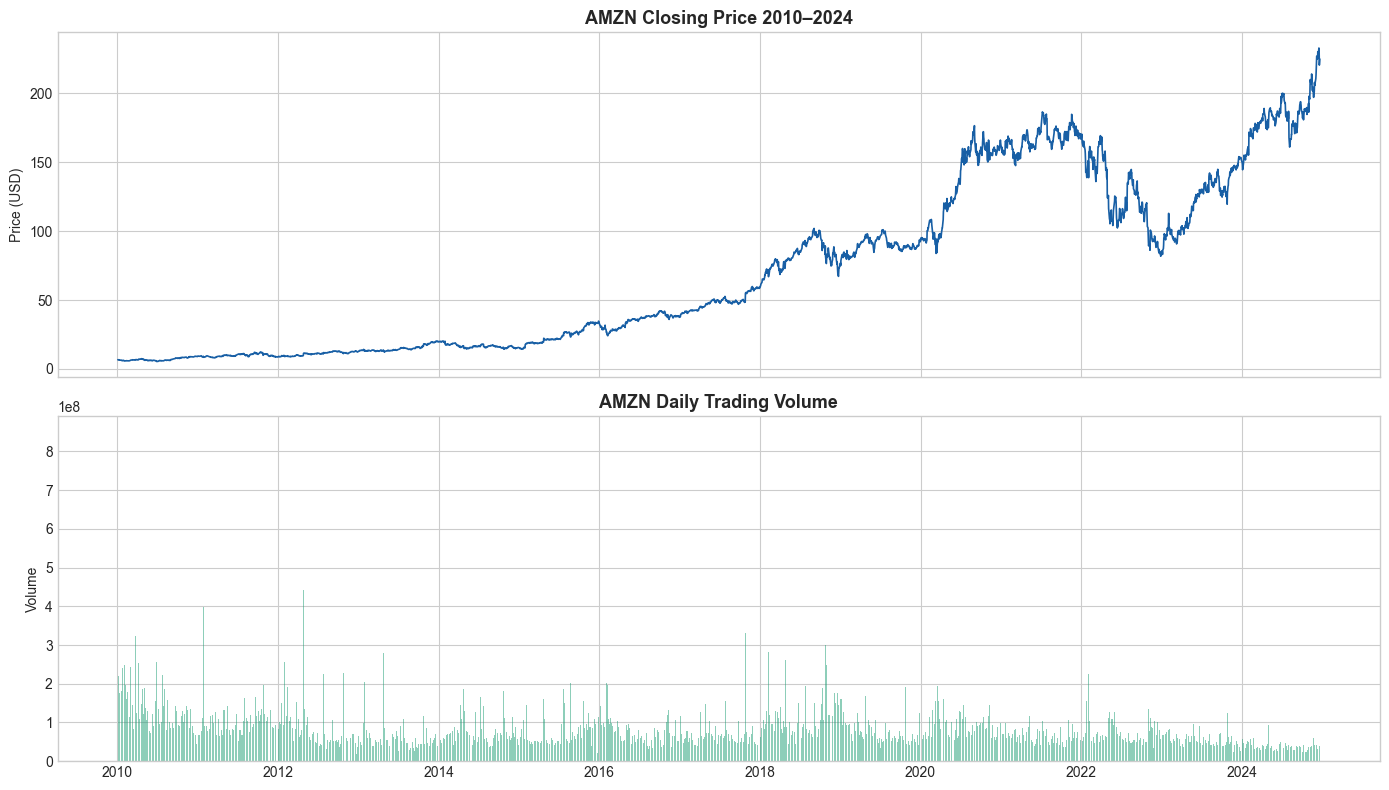

Saved to outputs/


In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(amzn['date'], amzn['close'], color='#185FA5', linewidth=1.2)
axes[0].set_title('AMZN Closing Price 2010–2024', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].bar(amzn['date'], amzn['volume'], color='#1D9E75', alpha=0.5, width=1)
axes[1].set_title('AMZN Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/amzn_price_volume.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

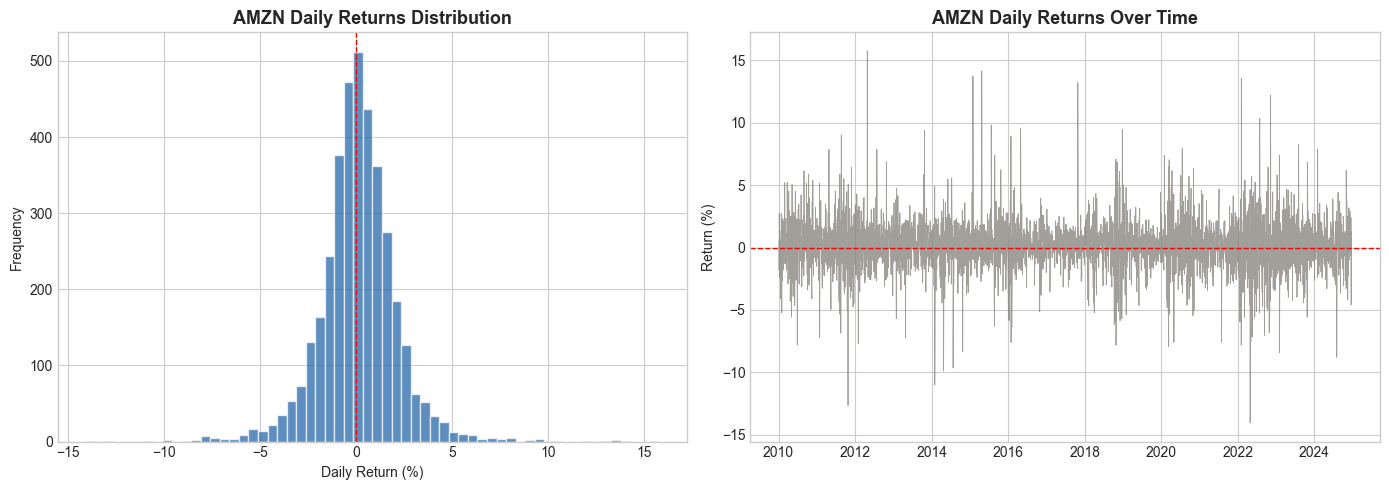

Mean daily return:    0.115%
Volatility (std dev): 2.062%
Max single-day gain:  15.75%
Max single-day loss:  -14.05%


In [41]:
amzn['daily_return'] = amzn['close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(amzn['daily_return'].dropna(), bins=60,
             color='#185FA5', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('AMZN Daily Returns Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')

axes[1].plot(amzn['date'], amzn['daily_return'],
             color='#888780', linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('AMZN Daily Returns Over Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/amzn_returns.png',
            dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean daily return:    {amzn['daily_return'].mean():.3f}%")
print(f"Volatility (std dev): {amzn['daily_return'].std():.3f}%")
print(f"Max single-day gain:  {amzn['daily_return'].max():.2f}%")
print(f"Max single-day loss:  {amzn['daily_return'].min():.2f}%")

In [42]:
# Observation AMZN daily returns are approximately normally distributed, centred near 0%. The standard deviation of 2.062% reflects Amazon's higher volatility compared to the broader market. 
# Periods of increased volatility are visible around 2020 (COVID) and 2022 (interest rate rises).

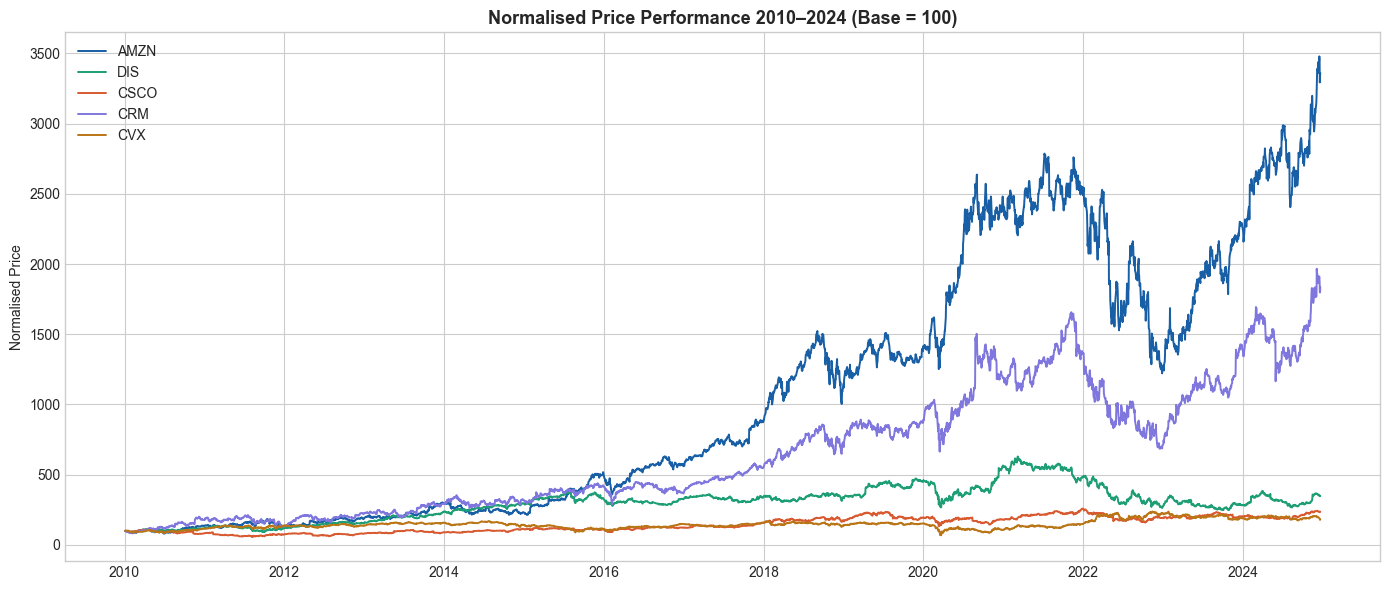

In [43]:
tickers = ['AMZN', 'DIS', 'CSCO', 'CRM', 'CVX']
colors  = ['#185FA5', '#1D9E75', '#D85A30', '#7F77DD', '#BA7517']

fig, ax = plt.subplots(figsize=(14, 6))

for ticker, color in zip(tickers, colors):
    stock = df_clean[df_clean['symbol'] == ticker].sort_values('date')
    normalised = stock['close'] / stock['close'].iloc[0] * 100
    ax.plot(stock['date'], normalised, label=ticker,
            color=color, linewidth=1.4)

ax.set_title('Normalised Price Performance 2010–2024 (Base = 100)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Normalised Price')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/multi_stock_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()

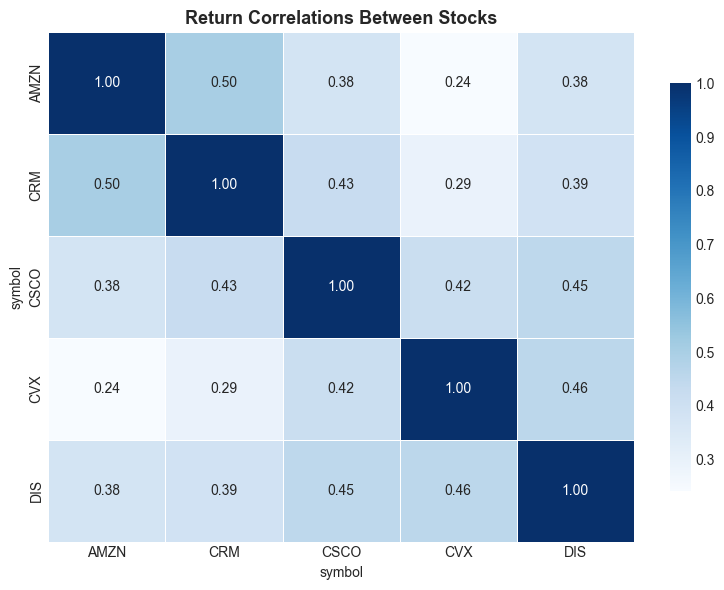

In [44]:
pivot = df_clean[df_clean['symbol'].isin(tickers)].pivot_table(
    index='date', columns='symbol', values='close'
)
returns_pivot = pivot.pct_change().dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(returns_pivot.corr(), annot=True, fmt='.2f',
            cmap='Blues', ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Return Correlations Between Stocks',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/LorenzoRoma/Github-S-P-500-Companies-Forecasting/outputs/correlation_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [46]:
# Observation AMZN and CRM (Salesforce) show the highest correlation, both being technology/growth stocks. CVX (Chevron, energy sector) shows the lowest correlation with the tech names, confirming that sector differences drive diversification benefits. 
# This is relevant context for our forecasting model.

In [47]:
print("=== EDA Complete ===")
print(f"Rows analysed:    {len(df_clean):,}")
print(f"Tickers:          {df_clean['symbol'].nunique()}")
print(f"Date range:       {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")
print(f"Focus stock:      AMZN")
print(f"Comparison set:   AMZN, DIS, CSCO, CRM, CVX")
print()
print("Charts saved:")
print("  outputs/amzn_price_volume.png")
print("  outputs/amzn_returns.png")
print("  outputs/multi_stock_comparison.png")
print("  outputs/correlation_heatmap.png")
print()
print("Next: Feature Engineering → notebooks/02_feature_engineering.ipynb")


=== EDA Complete ===
Rows analysed:    617,831
Tickers:          172
Date range:       2010-01-04 to 2024-12-20
Focus stock:      AMZN
Comparison set:   AMZN, DIS, CSCO, CRM, CVX

Charts saved:
  outputs/amzn_price_volume.png
  outputs/amzn_returns.png
  outputs/multi_stock_comparison.png
  outputs/correlation_heatmap.png

Next: Feature Engineering → notebooks/02_feature_engineering.ipynb


SyntaxError: invalid syntax (1522571603.py, line 1)